---
title: Constrained Quantum Optimizer - A Qiskit Function by Aqarios
description: Solve constrained binary optimization problems on IBM Quantum hardware by using the iterative warm-starting QAOA with XY-mixers by Aqarios.
---

{/* cspell:ignore Aqarios QOBLIB Bucher docplex forall Zachary quicksum */}

# Constrained Quantum Optimizer - A Qiskit Function by Aqarios

*See the [API reference](/docs/api/functions/aqarios-constrained-quantum-optimizer)*

<Admonition type="note">
  Qiskit Functions are an experimental feature available only to IBM Quantum&reg; Premium Plan, Flex Plan, and On-Prem (via IBM Quantum Platform API) Plan users. They are in preview release status and subject to change.
</Admonition>

## Overview

With the Constrained Quantum Optimizer by Aqarios, you can solve constrained binary optimization problems on IBM&reg; quantum hardware without manual reformulation and circuit mapping. Simply supply a problem as an LP file, an MPS file, or a [Luna Model](https://docs.aqarios.com/luna-model). The function handles reformulation, circuit synthesis, transpilation, and hardware execution automatically. The solver utilizes iterative warm-starting [\[1\]](#references) of the [FlexQAOA](https://docs.aqarios.com/luna-solve/algorithms/quantum-gate/flexqaoa/) algorithm, a constraint-native extension of the Quantum Approximate Optimization Algorithm (QAOA).

The optimizer targets binary problems with constraints. In particular, one-hot constraints and set-packing constraints can be natively enforced by using XY-mixers. Other constraint types are automatically reformulated as penalty terms.

## Description

The Constrained Quantum Optimizer implements the Iterative warm-start XY-mixer QAOA(IWS-QAOA) [\[1\]](#references). The algorithm runs fixed-angle QAOA circuits on quantum hardware and updates the initial warm-start probabilities of each circuit using measurement outcomes from the previous iteration. No variational parameter training is required; instead, a fixed linear ramp parametrization is chosen.

By using XY-mixers to enforce one-hot constraints, you can drastically improve solution quality for constrained problems, because the search space is practically reduced to a smaller feasible subspace &mdash; and no additional complexity, due to penalty terms, is introduced in the optimization landscape.

### Workflow

The workflow of the function is described below:

1. **Preprocessing**: Before circuit synthesis, the optimizer analyzes the constraint structure of the input problem:
    - _Graph preprocessing:_ When applicable to the problem, it is analyzed as a graph, where edges determine the relationship between variables. This graph analysis enables two preprocessing problem enhancements. First, single constraints can be aggregated to one large constraint by using clique merging, so that they are represented by a single XY-mixer. Second, variables with only a single neighbor can be fixed deterministically, reducing the problem size and complexity.
    - _Constraint resolution:_ The preprocessor handles each constraint separately: If the constraint is a one-hot constraint, it can be enforced through XY-mixers. If it is a set-packing constraint, it will first be transformed to a one-hot constraint. Equality constraints are handled through quadratic penalties, and inequality constraints through [unbalanced penalization](https://doi.org/10.1088/2058-9565/ad35e4).
    - _Penalty derivation:_ Constraints that cannot be expressed as one-hot equality constraints are converted to penalty terms. The optimizer derives the penalty strength automatically from the problem structure.
2. **Iterative warm-starting**: The optimizer runs multiple _parallel warm-start chains_. Each chain holds a probability distribution over variable assignments, which is used as the starting probability of the QAOA circuit (warm-start state). At each iteration, a chain samples from the quantum circuit, applies classical postprocessing, and updates its distribution based on the occurrence of samples. Across iterations, this focuses the search on high-quality solutions without a variational optimization loop.

The number of chains (`num_parallel`), the total shot budget per chain (`total_shots`), and the number of QAOA repetitions (`reps`) are the primary controls for trading solution quality against runtime.

![Workflow diagram of the Constrained Quantum Optimizer](/cqo-diagram.svg)

## Benchmarks

The benchmarks below show that the Constrained Quantum Optimizer Qiskit Function is capable of finding high quality, feasible solutions to constrained optimization problems with well above 100 binary variables. Accuracy is the ratio of the found objective value to the known optimum. Runtime is wall-clock time from function invocation to result delivery. QPU usage is the billable Quantum Compute time.

Two problems were examined: The [Maximum Independent Set](/docs/tutorials/find-the-maximum-independent-set-with-aqarios-constrained-quantum-optimizer) (MIS) problem and the Max-$k$-Cut, which is an extension of the well-known MaxCut problem to more than two categories. Max-$k$-Cut is also the optimization problem equivalent of the graph coloring decision problem (when all edges are cut, the graph is $k$-colorable).

| Problem               | Variables | Constraints | Qubits | Accuracy | Feasibility | Total runtime (s) | QPU usage (s) | Total shots |
|-----------------------|-----------|-------------|--------|----------|-------------|-------------------|---------------|-------------|
| MIS es60fst02         | 186       | 280         | 124    | 100.0%   | True        | 940.2             | 147.0         | 25.0k       |
| MIS sloane\_2dc\_128  | 128       | 5173        | 74     | 100.0%   | True        | 347.6             | 106.0         | 12.5k       |
| Max-3-Cut Karate Club | 99        | 33          | 99     | 98.7%    | True        | 279.5             | 166.0         | 25.0k       |
| Max-4-Cut Karate Club | 132       | 33          | 132    | 100.0%   | True        | 258.3             | 200.0         | 25.0k       |

### Benchmark Notes

- The above results were obtained on the `ibm_marrakesh` Heron r2 processor with default options and `use_session` enabled. For the `sloane_2dc_128` instance, `total_shots=12500` was used.
- The reduced qubit count for MIS instances (74 and 124 versus 128 and 186 variables) reflects variable fixing in preprocessing.
- The problem instances for MIS are taken from the [Quantum Optimization Benchmarking Library](https://doi.org/10.1038/s43588-026-00991-1). - The instance for the Max-$k$-Cut problem is the [Zachary Karate Club graph](https://en.wikipedia.org/wiki/Zachary%27s_karate_club), which has a chromatic number of 5.

## Get started

This guide demonstrates basic usage of the Constrained Quantum Optimizer by showing how to load the function and execute simple problems. For a more involved tutorial, see [Find the Maximum Independent Set with the Aqarios Constrained Quantum Optimizer](/docs/tutorials/find-the-maximum-independent-set-with-aqarios-constrained-quantum-optimizer).

Authenticate with your IBM Quantum API key and instance CRN, then load the function from the catalog.

<Admonition type="note">
  The following code assumes you have saved your credentials. To set them up, follow the instructions in [Save your IBM Cloud account credentials](/docs/guides/functions-get-started#install-qiskit-functions-catalog-client).
</Admonition>

In [ ]:
from qiskit_ibm_catalog import QiskitFunctionsCatalog

catalog = QiskitFunctionsCatalog(channel="ibm_quantum_platform")

# Verify that you have access to the function
catalog.list()

[QiskitFunction(aqarios/constrained-quantum-optimizer)]

In [ ]:
# Load the function
optimizer = catalog.load("aqarios/constrained-quantum-optimizer")

In [3]:
# Check the list of backends you have access to
catalog.backends()

[<IBMBackend('ibm_pittsburgh')>,
 <IBMBackend('ibm_boston')>,
 <IBMBackend('ibm_phoenix')>,
 <IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_miami')>,
 <IBMBackend('ibm_marrakesh')>,
 <IBMBackend('ibm_kingston')>]

In [4]:
# Select the backend you want to use
backend = catalog.backend("ibm_phoenix")

## Example 1: A simple constrained problem

The first example shows how to use the function with [LP-files](https://www.ibm.com/docs/en/icos/22.1.1?topic=cplex-lp-file-format-algebraic-representation), a common optimization problem specification used in operations research. You will formulate the following arbitrary optimization problem of five binary variables $x_i \in \{0,1\}$ subject to two constraints:
$$
    \min x_1 x_2 + 2 x_2 x_3 - x_3 x_4 - 2 x_4 x_5 - 2 x_1 x_3 - 4 x_2 x_5 \\
    \text{s.t.}\quad x_1 + x_2 + x_3 \leq 1 \\
    \quad x_3 - x_4 + x_5 = 0
$$

### 1. Formulate the problem

Directly state the mathematical expression as the following LP-string format:

In [5]:
lp_str = """\\Problem name: Example
Minimize
  obj: [ 2 x_1 x_2 + 4 x_2 x_3 - 2 x_3 x_4 - 4 x_4 x_5 - 4 x_1 x_3 - 8 x_2 x_5 ] / 2
Subject To
  c1: x_1 + x_2 + x_3 <= 1
  c2: x_3 - x_4 + x_5 = 0
Binaries
  x_1 x_2 x_3 x_4 x_5
End
"""

Note that `[ ... ] / 2` is a required notation for quadratic objectives from the LP standard.

### 2. Run the optimizer

Solve the problem with the optimizer.

In [ ]:
# Set up low-resource options for the simple problem
options = {"total_shots": 2000, "num_parallel": 5, "use_session": True}

# Dispatch the job
job_1 = optimizer.run(model=lp_str, backend_name=backend.name, options=options)

print(f"Job ID: {job_1.job_id}")

Job ID: 2e06a3a8-7c29-4c76-94d7-194293363f4a


In [7]:
# Monitor the job status
job_1.status()

'RUNNING: WAITING_FOR_QPU'

### 3. Retrieve the result

The solution, mapping the variable names to the associated assignments, is provided by the result.

In [8]:
result = job_1.result()

result

{'solutions': [{'x_1': 0, 'x_2': 1, 'x_3': 0, 'x_4': 1, 'x_5': 1}],
 'raw_energy': -6.0,
 'obj_value': -6.0,
 'feasible': True,
 'metadata': {'resource_usage': {'RUNNING: MAPPING': {'CPU': 5.405},
   'RUNNING: OPTIMIZING_FOR_HARDWARE': {'CPU': 9.902},
   'RUNNING: WAITING_FOR_QPU': {'CPU': 25.456},
   'RUNNING: EXECUTING_QPU': {'CPU': 25.202},
   'RUNNING: POST_PROCESSING': {'CPU': 6.481}},
  'circuit_metrics': {'depth': 100.95,
   '2Q-depth': 33.0,
   'sx': 122.25,
   'rz': 78.85,
   'cz': 48.0,
   'x': 0.4}}}

The `solutions` field in the return dictionary contains all degenerate best solutions found. Alongside the solution data, the `obj_value`, a `feasible` flag, and additional `metadata` are provided.

## Example 2: Maximum Independent Set

The Maximum Independent Set (MIS) problem asks for the largest subset of vertices in a graph such that no two vertices in the subset share an edge. This example solves MIS on a 12-node regular graph. For more information on the problem and a larger example, refer to the [tutorial](/docs/tutorials/find-the-maximum-independent-set-with-aqarios-constrained-quantum-optimizer).

The problem is built with [qiskit-addon-opt-mapper](https://github.com/qiskit/qiskit-addon-opt-mapper).
Install the required packages if needed:

In [5]:
# %pip install networkx qiskit-addon-opt-mapper

### Step 1: Define the problem

Build a random 3-regular graph and create the MIS optimization problem. Each graph node becomes a binary variable, and each edge introduces a constraint ensuring that at most one endpoint is selected.

In [9]:
import networkx as nx
from qiskit_addon_opt_mapper.applications import IndependentSet
from qiskit_addon_opt_mapper.translators import to_docplex_mp

# 12-node random 3-regular graph
G = nx.random_regular_graph(3, 12, seed=7)

# Build MIS problem and export as LP string
mis = IndependentSet(G)
mis_problem = mis.to_optimization_problem()
lp_str = to_docplex_mp(mis_problem).export_as_lp_string()

print(lp_str)

\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: Independent set

Maximize
 obj: x_0 + x_1 + x_2 + x_3 + x_4 + x_5 + x_6 + x_7 + x_8 + x_9 + x_10 + x_11
Subject To
 c0: x_0 + x_4 <= 1
 c1: x_0 + x_9 <= 1
 c2: x_0 + x_8 <= 1
 c3: x_1 + x_2 <= 1
 c4: x_1 + x_7 <= 1
 c5: x_1 + x_3 <= 1
 c6: x_2 + x_4 <= 1
 c7: x_2 + x_11 <= 1
 c8: x_3 + x_10 <= 1
 c9: x_3 + x_11 <= 1
 c10: x_4 + x_5 <= 1
 c11: x_5 + x_10 <= 1
 c12: x_5 + x_6 <= 1
 c13: x_6 + x_8 <= 1
 c14: x_6 + x_7 <= 1
 c15: x_7 + x_9 <= 1
 c16: x_8 + x_11 <= 1
 c17: x_9 + x_10 <= 1

Bounds
 0 <= x_0 <= 1
 0 <= x_1 <= 1
 0 <= x_2 <= 1
 0 <= x_3 <= 1
 0 <= x_4 <= 1
 0 <= x_5 <= 1
 0 <= x_6 <= 1
 0 <= x_7 <= 1
 0 <= x_8 <= 1
 0 <= x_9 <= 1
 0 <= x_10 <= 1
 0 <= x_11 <= 1

Binaries
 x_0 x_1 x_2 x_3 x_4 x_5 x_6 x_7 x_8 x_9 x_10 x_11
End



### Step 2: Run the optimizer

Solve the problem with the optimizer.

In [10]:
options = {"total_shots": 2000, "use_session": True}

# Dispatch the job
job_2 = optimizer.run(model=lp_str, backend_name=backend.name, options=options)

print(f"Job ID: {job_2.job_id}")

Job ID: f041431c-b42e-4627-afe5-522fea61faf6


In [11]:
# Monitor the job status
job_2.status()

'QUEUED'

### Step 3: Retrieve and interpret results

Finally we retrieve the solution and verify for correctness.

In [12]:
result = job_2.result()

print(f"Feasible: {result['feasible']}")
print(f"Independent set size: {int(result['obj_value'])}")

# Extract the selected nodes
solution = result["solutions"][0]
independent_set = [int(k.split("_")[1]) for k, v in solution.items() if v == 1]
print(f"Selected nodes: {sorted(independent_set)}")

# Verify no two selected nodes share an edge
conflicts = [
    (u, v) for u, v in G.edges() if u in independent_set and v in independent_set
]
print(f"Edge conflicts: {conflicts}")

Feasible: True
Independent set size: 5
Selected nodes: [1, 4, 6, 9, 11]
Edge conflicts: []


## Example 3: Graph 3-coloring (Max-3-Cut)

The Max-$k$-Cut problem partitions the vertices of a graph into $k$ groups to maximize the number of edges whose endpoints belong to different groups. For $k = 3$ this is equivalent to finding a 3-coloring that maximizes cross-color edges.

Formally, assign each node $i \in V$ to one of $k$ groups with binary variables $x_{i,c}$ for color $c \in \{1, \ldots, k\}$. The one-hot constraint $\sum_c x_{i,c} = 1$ for each node enforces a unique assignment. The objective maximizes cross-group edges:

$$
\min \sum_{(u,v) \in E} \sum_c x_{u,c} \, x_{v,c}\\
\text{s.t.} \sum_{c} x_{i,c} = 1 \quad \forall i \in  V
$$

The one-hot constraints are ideal for XY-mixers, which the optimizer handles natively.

This example uses the [Zachary Karate Club graph](https://en.wikipedia.org/wiki/Zachary%27s_karate_club) (34 nodes, 78 edges) and builds the model with the [Luna Model](https://docs.aqarios.com/luna-model/).
Install the required packages if needed:

In [9]:
# %pip install networkx matplotlib luna-model

### Step 1: Define the problem

First, generate the binary variables with the `luna-model` package. Then, define the objective and add the constraints to the model.

In [13]:
import networkx as nx
from luna_model import Model, quicksum

k = 3
G = nx.karate_club_graph()

# Instantiate the Model object
model = Model(name="Max-3-Cut")

# Add binary variables
x = model.add_variables("x", shape=(G.number_of_nodes(), k))

# Add the objective by using the numpy dot abstraction
model.objective = quicksum(x[i].dot(x[j]) for i, j in G.edges)

# Bulk-add the one-hot constraints
model.add_constraints(x.sum(axis=1) == 1)

# Encode the model to send via API
model_enc = model.encode_b64()

### Step 2: Run the optimizer

Solve the problem with the optimizer.

In [ ]:
options = {"use_session": True}

# Dispatch the job
job_3 = optimizer.run(model=model_enc, backend_name=backend.name, options=options)

print(f"Job ID: {job_3.job_id}")

Job ID: df911d83-9df7-44a1-bfad-5d66e08676c3


In [15]:
# Monitor the job status
job_3.status()

'RUNNING: WAITING_FOR_QPU'

### Step 3: Retrieve and visualize results

Retrieve and visualize the results.

Feasible: True
Violations: 4


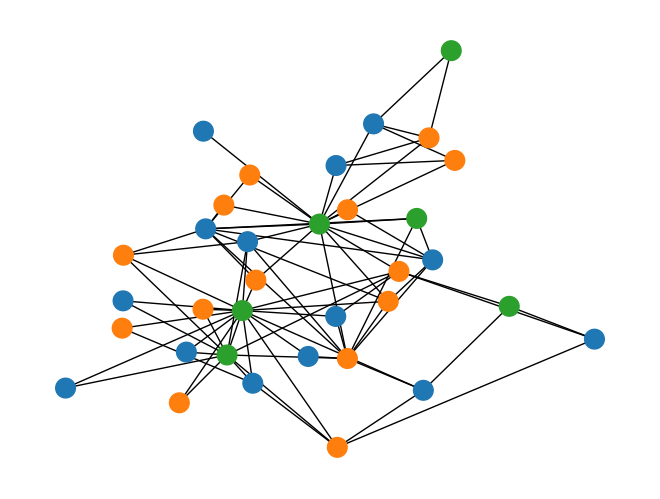

In [16]:
result = job_3.result()
solution = result["solutions"][0]

# Map each node to its assigned color group
node_group = {}
for i in G.nodes:
    for c in range(k):
        if solution[f"x{i},{c}"] == 1:
            node_group[i] = c

print(f"Feasible: {result['feasible']}")
print(f"Violations: {int(result['obj_value'])}")

# Visualize the partition
colors = ["tab:blue", "tab:orange", "tab:green"]
node_colors = [colors[node_group[i]] for i in G.nodes()]
nx.draw(G, nx.kamada_kawai_layout(G), node_color=node_colors, node_size=200)

## Get support

For questions or issues, contact [support@aqarios.com](mailto:support@aqarios.com) with your job ID.

## Next steps

<Admonition type="tip" title="Recommendations">
  * [Request access to the Constrained Quantum Optimizer by Aqarios](https://aqarios.com/qiskit-function-access/).
  * Visit the [API reference](/docs/api/functions/aqarios-constrained-quantum-optimizer) for the complete parameter and output documentation.
  * Try the [Find the Maximum Independent Set with the Aqarios Constrained Quantum Optimizer](/docs/tutorials/find-the-maximum-independent-set-with-aqarios-constrained-quantum-optimizer) tutorial for a deep-dive into a real QOBLIB benchmark instance.
  * Review the publication [Constrained Quantum Optimization via Iterative Warm-Start XY-Mixers](https://doi.org/10.1088/1367-2630/ae8ea2).
</Admonition>

## References

1. Bucher et al. (2026), *Constrained Quantum Optimization via Iterative Warm-Start XY-Mixers* [10.1088/1367-2630/ae8ea2](https://doi.org/10.1088/1367-2630/ae8ea2)